# Perth historical FCN validation

Three fixed seasonal cases initialized 2022-01-01, 2022-07-01, and 2022-10-01 at 00 UTC.
Each runs for ten days at six-hour intervals from ERA5, deriving the two required
relative-humidity fields through Earth2Studio's ECMWF mixed-phase diagnostic.

Generate or resume the complete data pipeline with `pixi run validate` at the repository
root. This notebook reads the committed score tables and figures; it does not download
data or rerun the GPU forecast. Full observation pairs and ERA5 truth snapshots remain
under `outputs/historical/` for audit and replay.


In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
from IPython.display import Image, display
root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pixi.toml").exists())
report = root / "reports" / "phase1"
grid = pd.read_csv(report / "grid_scores.csv")
station = pd.read_csv(report / "station_scores.csv")
metadata = json.loads((report / "metadata.json").read_text())
print(metadata["case_selection"])
display(pd.DataFrame([{"case": c["case"], "initial ERA5 max error": c["initial_max_abs_error"]} for c in metadata["cases"]]))


Fixed 2022 summer, winter, spring dates chosen before scores; not selected extreme events


,case,initial ERA5 max error
0,2022-01-01,0.0
1,2022-07-01,0.0
2,2022-10-01,0.0


## ERA5 and persistence

Scores reduce latitude/longitude with cosine-latitude weights. Both forecasts use the
same finite verification mask. Persistence holds the initial ERA5 analysis at all leads.
Lead zero is excluded. Curves pool the three cases as the square root of mean squared
RMSE, giving each case equal weight. The z500 variable is geopotential in m²/s².


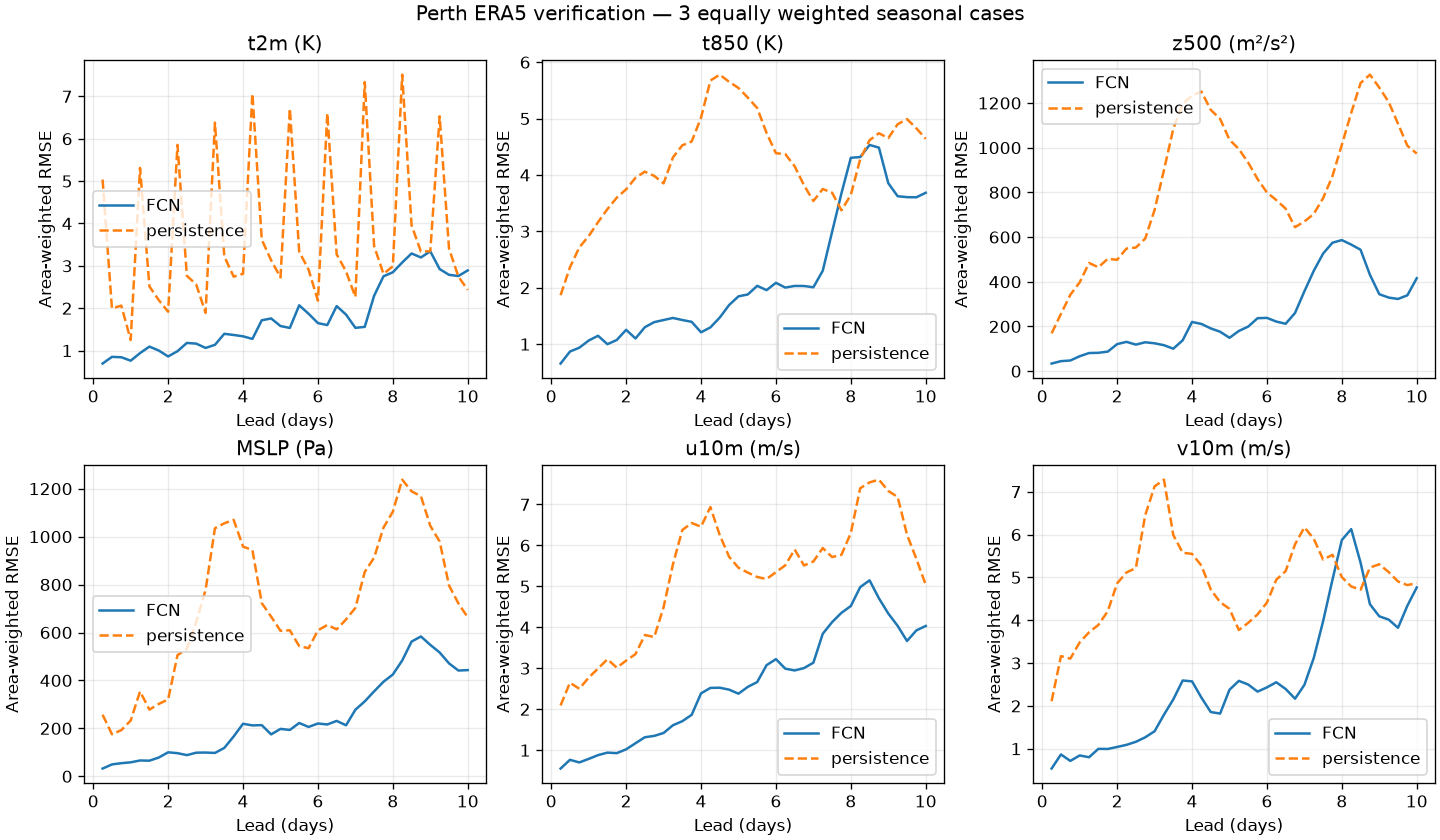

model                    FCN  persistence  RMSE skill vs persistence
variable lead_hours                                                 
msl      24.0         58.329      232.573                      0.749
         120.0       197.884      607.085                      0.674
         240.0       443.097      663.258                      0.332
t2m      24.0          0.762        1.250                      0.391
         120.0         1.580        2.728                      0.421
         240.0         2.893        2.432                     -0.189
t850     24.0          1.063        2.916                      0.635
         120.0         1.847        5.543                      0.667
         240.0         3.684        4.641                      0.206
u10m     24.0          0.788        2.772                      0.716
         120.0         2.380        5.454                      0.564
         240.0         4.033        5.037                      0.199
v10m     24.0          0.843        3.483                      0.758
         120.0         2.378        4.266                      0.443
         240.0         4.765        4.867                      0.021
z500     24.0         66.790      397.285                      0.832
         120.0       149.376     1035.667                      0.856
         240.0       415.933      973.724                      0.573

In [2]:
display(Image(filename=str(report / "era5_rmse.png")))
selected = grid.loc[grid.lead_hours.isin([24, 120, 240])]
summary = selected.assign(mse=selected.rmse**2).groupby(["variable", "lead_hours", "model"]).mse.mean().pow(0.5).unstack("model")
summary["RMSE skill vs persistence"] = 1 - summary.FCN / summary.persistence
display(summary.round(3))


## Airport verification

Nearest model grid point to YPPH; nearest finite report per variable within ±30 minutes.
Temperature is K (error magnitudes equal °C), wind m/s, pressure Pa. Station persistence
uses the latest report at or before initialization within that tolerance. Both models
are scored on shared finite pairs; missing baselines or observations are counted, not filled.
No-pair metrics remain NaN. Archive quality control, model terrain and airport exposure
limit interpretation. Pressure is compared only when an actual MSLP report exists.


,case,variable,model,units,n_expected,n_matched,rmse,bias,mae
0,2022-01-01,msl,FCN,Pa,40,0,NaN,NaN,NaN
1,2022-01-01,t2m,FCN,K,40,40,3.356,2.392,2.777
2,2022-01-01,u10m,FCN,m s-1,40,40,3.631,-0.833,3.024
3,2022-01-01,v10m,FCN,m s-1,40,40,2.452,-0.889,2.017
4,2022-01-01,ws10m,FCN,m s-1,40,40,2.983,-1.471,2.566
5,2022-01-01,msl,persistence,Pa,40,0,NaN,NaN,NaN
6,2022-01-01,t2m,persistence,K,40,40,6.721,-4.125,5.025
7,2022-01-01,u10m,persistence,m s-1,40,40,6.100,-3.487,4.906
8,2022-01-01,v10m,persistence,m s-1,40,40,3.160,2.125,2.603
9,2022-01-01,ws10m,persistence,m s-1,40,40,2.232,0.450,1.813


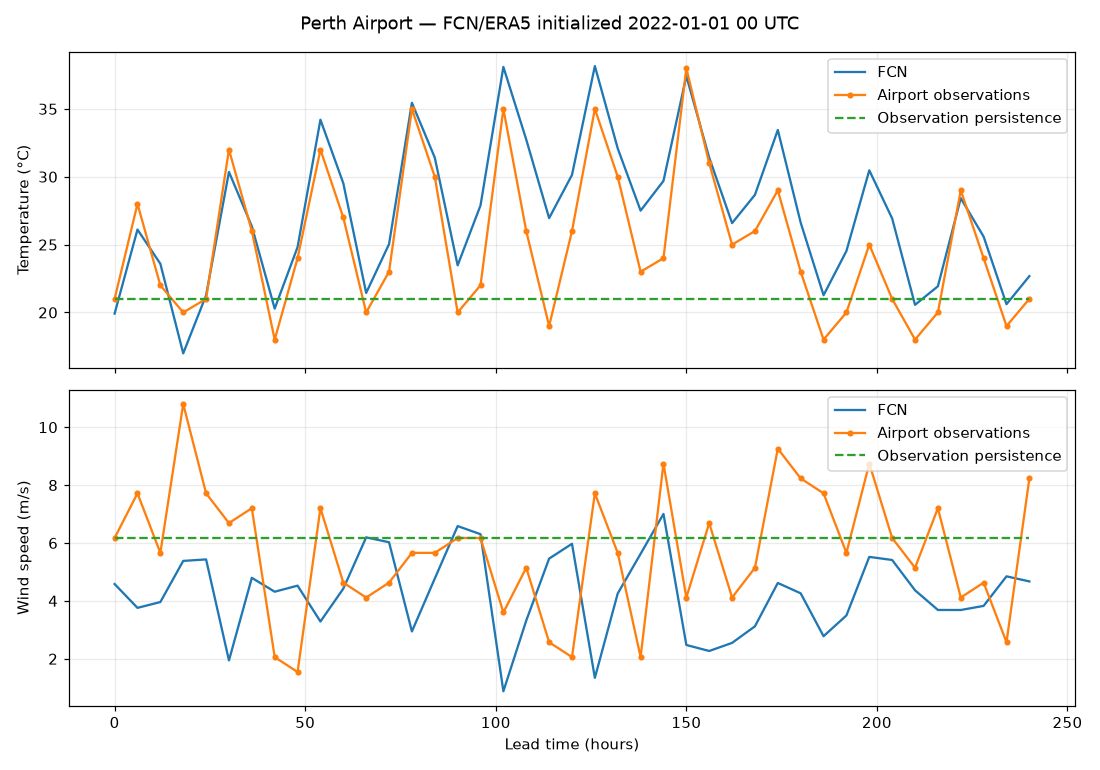

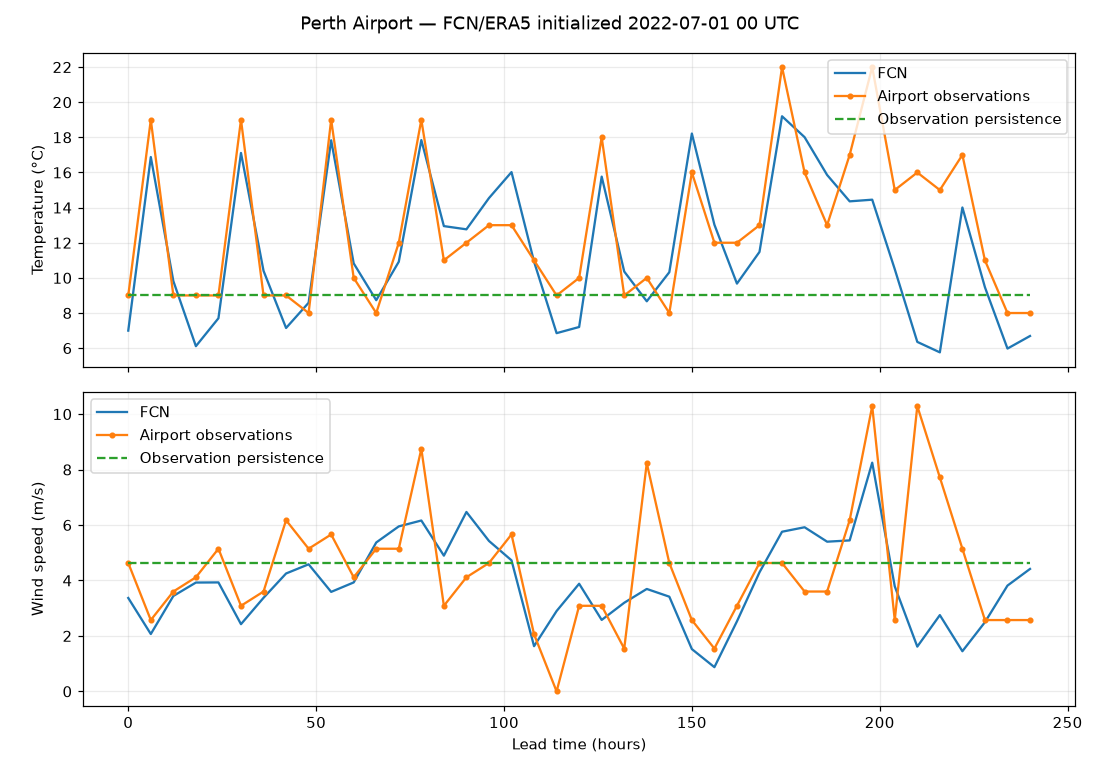

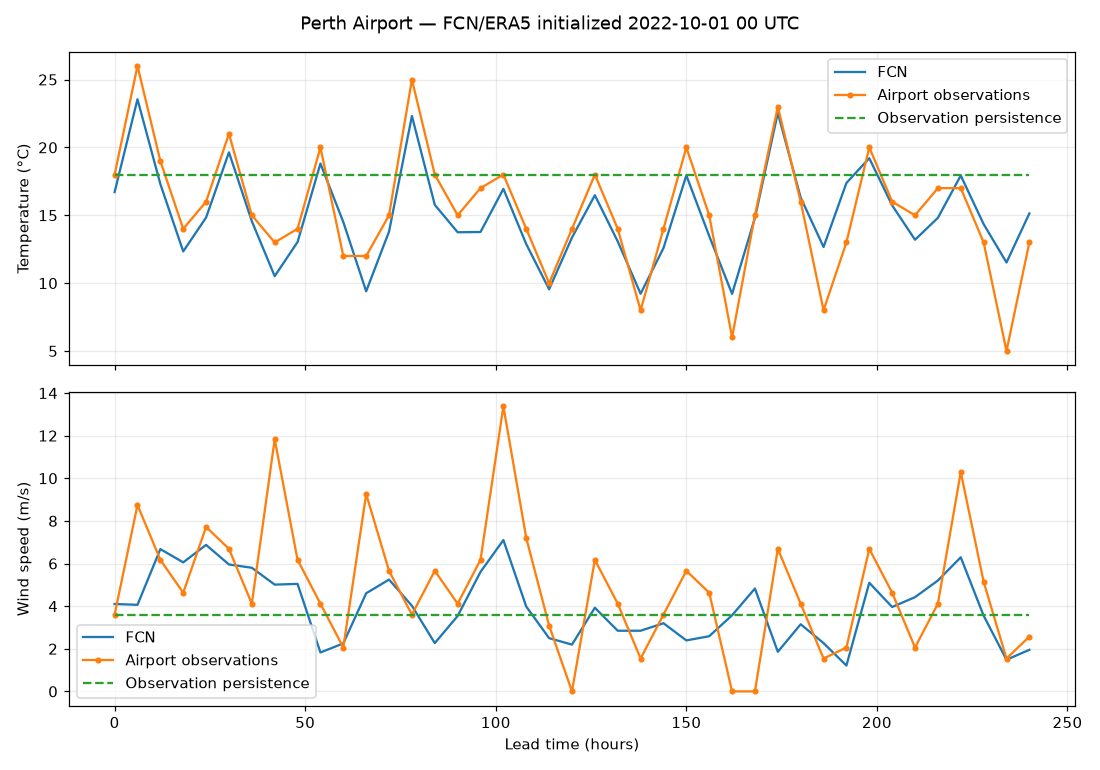

In [3]:
display(station[["case", "variable", "model", "units", "n_expected", "n_matched", "rmse", "bias", "mae"]].round(3))
for case in sorted(grid.case.unique()):
    display(Image(filename=str(report / f"{case}-station.png")))


## Spatial sanity checks

Perth-domain temperature at +24, +120 and +240 h, alongside verifying ERA5 and forecast
error. The black point marks Perth Airport. These are deterministic 0.25° fields;
there is no city-scale downscaling or uncertainty estimate.


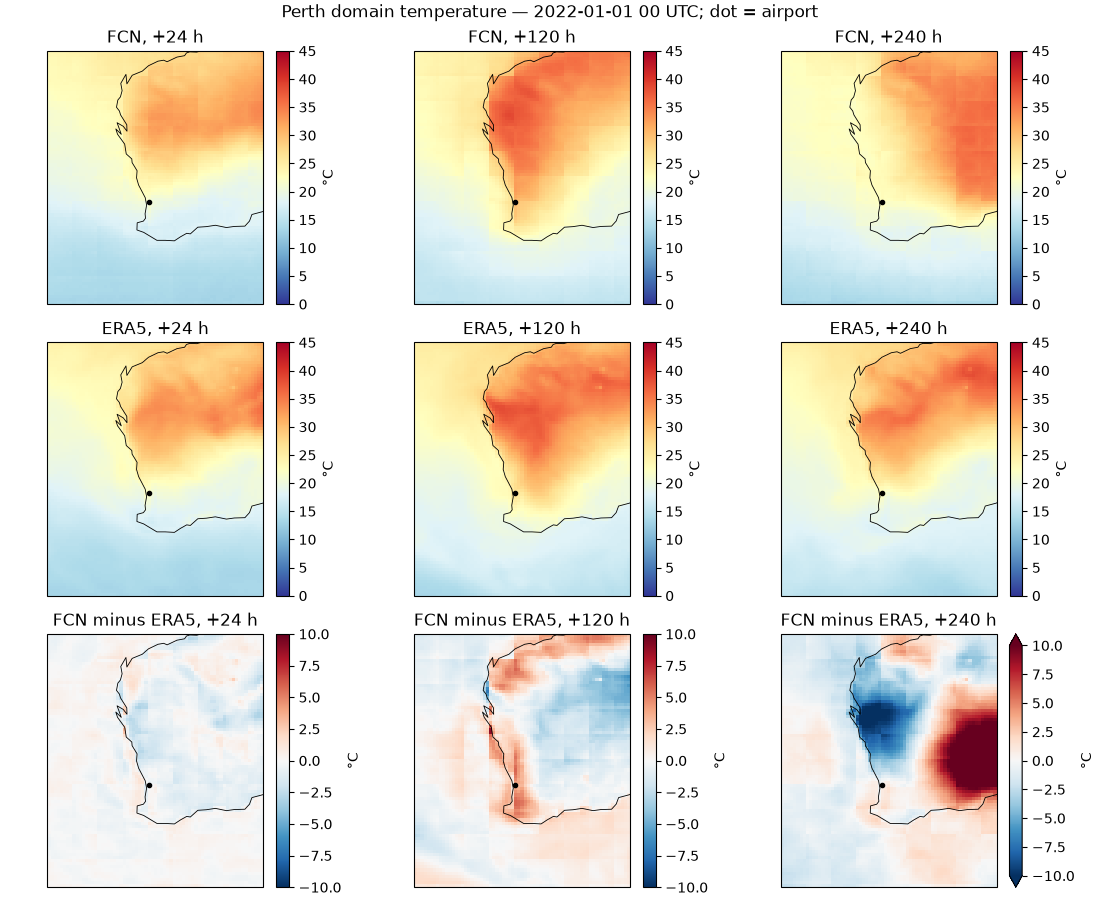

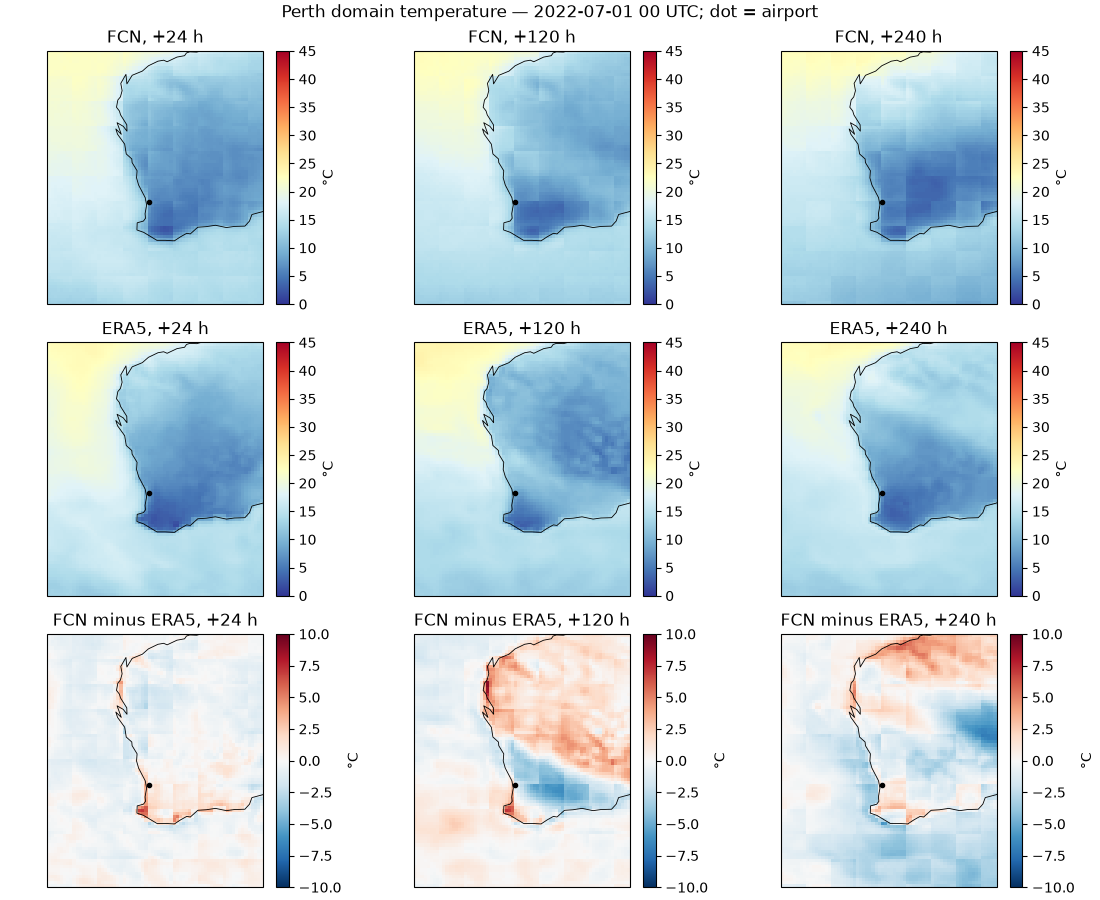

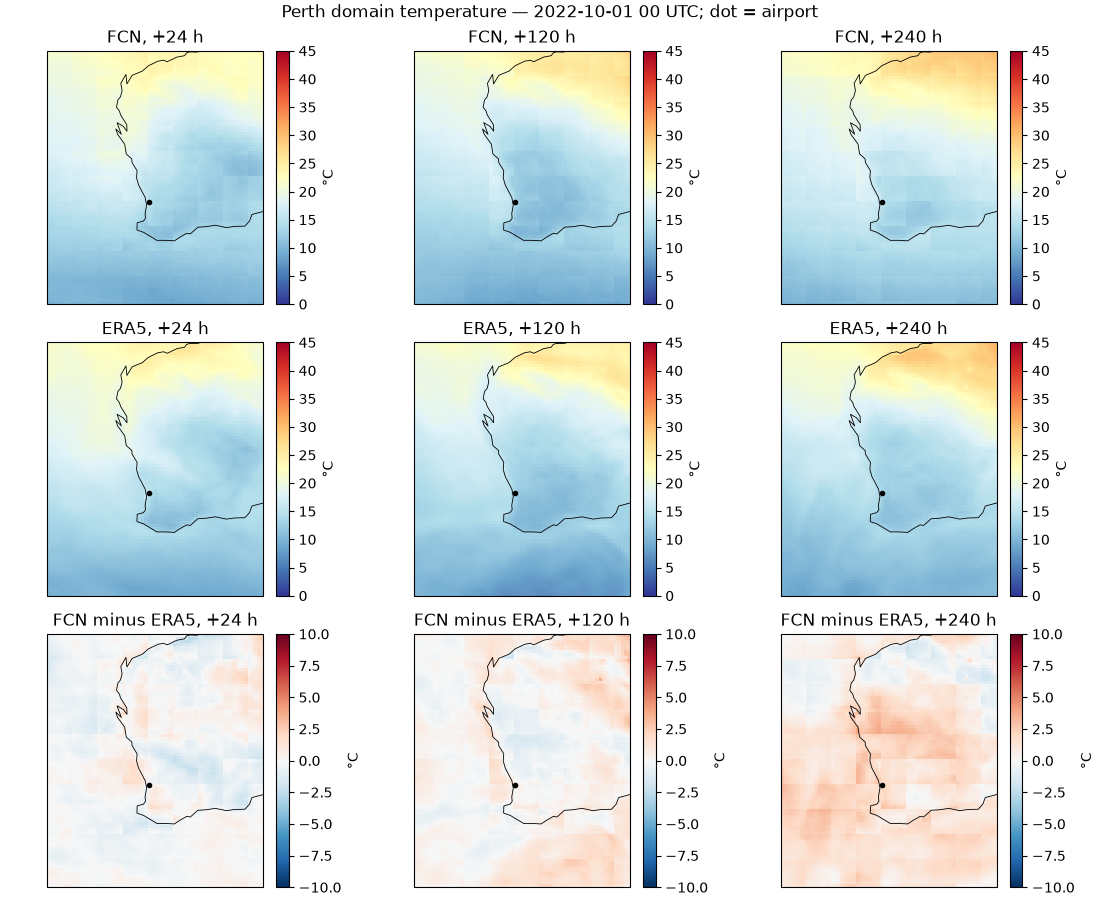

In [4]:
for case in sorted(grid.case.unique()):
    display(Image(filename=str(report / f"{case}-maps.png")))


## Interpretation limits and next work

Three dates sample seasons, not a representative climatology or a set of independently
confirmed extreme events. The model card lists training in 1980–2015 and evaluation
through 2019; these 2022 cases are later. ERA5 is a reanalysis and initialization source,
not an independent station observation. There is no multi-year climatology here, so ACC
is deliberately not reported. GFS forecast comparison, Perth Metro, more cases, and
climatological skill/uncertainty estimates remain future work. See
`plan/13_historical_validation.md` for the written results and sources.
